___
                     Never assume the complex model is better. Prove it.
___

In [5]:
from pathlib import Path
import time
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [6]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

MODELS_DIR = ARTIFACTS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DIR)
print("Models directory:", MODELS_DIR)

Project root: d:\industrial-predictive-maintenance
Processed data: d:\industrial-predictive-maintenance\data\processed
Models directory: d:\industrial-predictive-maintenance\artifacts\models


In [7]:
train_data = np.load(PROCESSED_DIR / "train_sequences.npz")
val_data = np.load(PROCESSED_DIR / "val_sequences.npz")
test_data = np.load(PROCESSED_DIR / "test_sequences.npz")

X_train = train_data["X"]
y_train = train_data["y"]

X_val = val_data["X"]
y_val = val_data["y"]

X_test = test_data["X"]
y_test = test_data["y"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (12407, 30, 15)
y_train: (12407,)
X_val: (2612, 30, 15)
y_val: (2612,)
X_test: (2612, 30, 15)
y_test: (2612,)


### Helper functions

We'll centralize evaluation instead of repeatedly writing the same code.

In [8]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    return {
        "MAE": mae,
        "RMSE": rmse
    }

In [9]:
def evaluate_model(model_name, y_true, y_pred):
    metrics = calculate_metrics(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"]
    }

In [10]:
mean_rul = y_train.mean()

print("Mean RUL:", mean_rul)

Mean RUL: 94.78367050858387


In [11]:
mean_val_predictions = np.full(
    len(y_val),
    mean_rul
)

In [12]:
mean_val_metrics = evaluate_model(
    "Mean Baseline",
    y_val,
    mean_val_predictions
)

mean_val_metrics

{'Model': 'Mean Baseline',
 'MAE': 48.63189647053712,
 'RMSE': np.float64(57.80757648019436)}

#### Our sequence is:

                samples × timesteps × sensors

#### Classical ML requires:

                samples × features

In [13]:
def create_statistical_features(X):
    mean_features = X.mean(axis=1)

    std_features = X.std(axis=1)

    min_features = X.min(axis=1)

    max_features = X.max(axis=1)

    latest_features = X[:, -1, :]

    trend_features = X[:, -1, :] - X[:, 0, :]

    features = np.concatenate(
        [
            mean_features,
            std_features,
            min_features,
            max_features,
            latest_features,
            trend_features
        ],
        axis=1
    )

    return features

In [14]:
X_train_features = create_statistical_features(X_train)

X_val_features = create_statistical_features(X_val)

X_test_features = create_statistical_features(X_test)

In [15]:
print("Original sequence shape:")
print(X_train.shape)

print("\nStatistical feature shape:")
print(X_train_features.shape)

Original sequence shape:
(12407, 30, 15)

Statistical feature shape:
(12407, 90)


## linear regression

In [16]:
linear_model = LinearRegression()

linear_model.fit(
    X_train_features,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](90,)","[-16.58, 10.95,-25.7 ,..., -2.31, 2.13, 1.77]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,166.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,90
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(89)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](90,)","[637.77,308.05,250.23,..., 2.35, 1.73, 0. ]"


In [17]:
linear_val_predictions = linear_model.predict(
    X_val_features
)

In [18]:
linear_val_metrics = evaluate_model(
    "Linear Regression",
    y_val,
    linear_val_predictions
)

linear_val_metrics

{'Model': 'Linear Regression',
 'MAE': 25.58716602403937,
 'RMSE': np.float64(32.80793662274666)}

## Random Forest

In [19]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [20]:
rf_model.fit(
    X_train_features,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [21]:
rf_val_predictions = rf_model.predict(
    X_val_features
)

In [22]:
rf_val_metrics = evaluate_model(
    "Random Forest",
    y_val,
    rf_val_predictions
)

rf_val_metrics

{'Model': 'Random Forest',
 'MAE': 26.003397779479325,
 'RMSE': np.float64(37.879544651125975)}

### Compare baselines

In [23]:
baseline_results = pd.DataFrame([
    mean_val_metrics,
    linear_val_metrics,
    rf_val_metrics
])

baseline_results = baseline_results.sort_values(
    "RMSE"
).reset_index(drop=True)

baseline_results

,Model,MAE,RMSE
0,Linear Regression,25.587166,32.807937
1,Random Forest,26.003398,37.879545
2,Mean Baseline,48.631896,57.807576


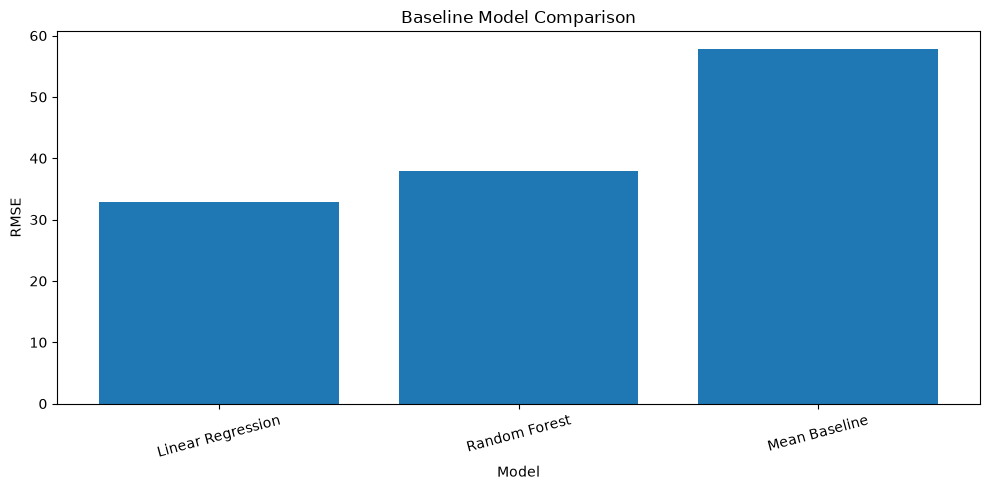

In [24]:
plt.figure(figsize=(10, 5))

plt.bar(
    baseline_results["Model"],
    baseline_results["RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Baseline Model Comparison")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

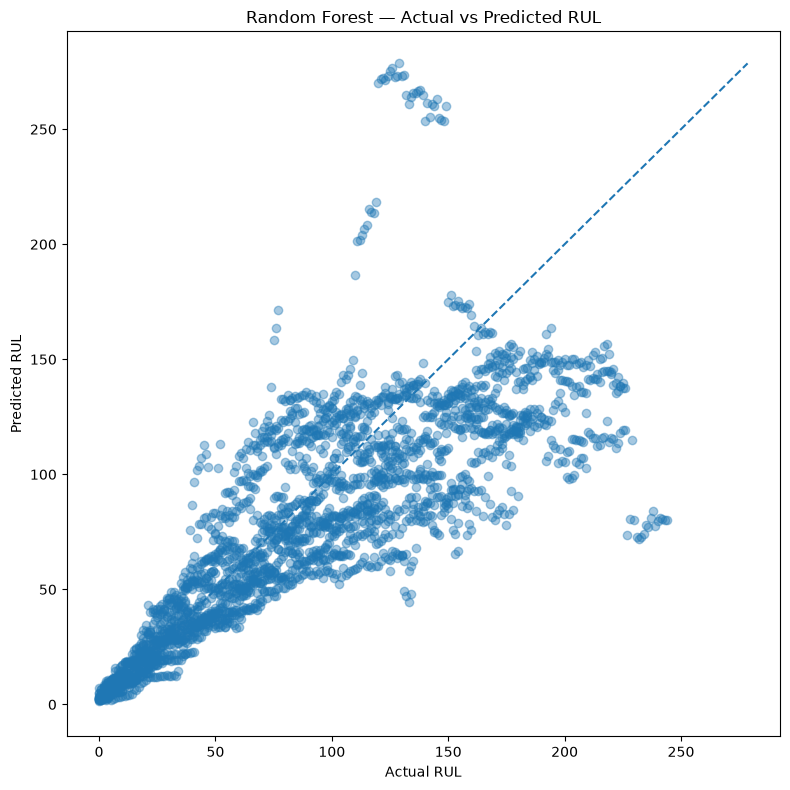

In [25]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_val,
    rf_val_predictions,
    alpha=0.4
)

min_value = min(
    y_val.min(),
    rf_val_predictions.min()
)

max_value = max(
    y_val.max(),
    rf_val_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Random Forest — Actual vs Predicted RUL")

plt.tight_layout()
plt.show()

### residuals analysis


In [26]:
rf_residuals = y_val - rf_val_predictions

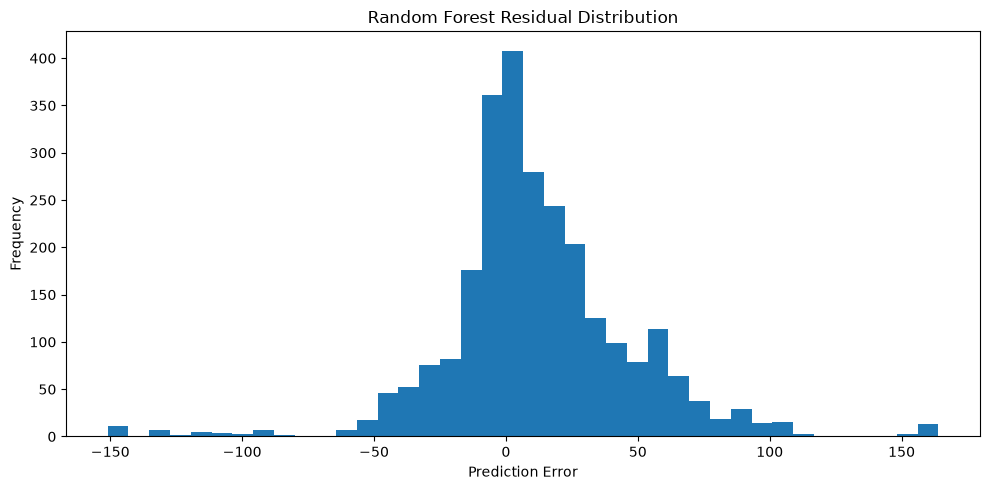

In [27]:
plt.figure(figsize=(10, 5))

plt.hist(
    rf_residuals,
    bins=40
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Random Forest Residual Distribution")

plt.tight_layout()
plt.show()

In [28]:
rf_model_path = (
    MODELS_DIR /
    "random_forest_baseline.joblib"
)

joblib.dump(
    rf_model,
    rf_model_path
)

print("Saved:", rf_model_path)

Saved: d:\industrial-predictive-maintenance\artifacts\models\random_forest_baseline.joblib


In [29]:
linear_model_path = (
    MODELS_DIR /
    "linear_regression_baseline.joblib"
)

joblib.dump(
    linear_model,
    linear_model_path
)

print("Saved:", linear_model_path)

Saved: d:\industrial-predictive-maintenance\artifacts\models\linear_regression_baseline.joblib


In [30]:
results_path = (
    ARTIFACTS_DIR /
    "baseline_results.csv"
)

baseline_results.to_csv(
    results_path,
    index=False
)

print("Saved:", results_path)

Saved: d:\industrial-predictive-maintenance\artifacts\baseline_results.csv


# Final validation report

In [31]:
print("=" * 60)
print("BASELINE MODEL VALIDATION")
print("=" * 60)

print(baseline_results.to_string(index=False))

print("\nBest model by RMSE:")
print(
    baseline_results.iloc[
        baseline_results["RMSE"].argmin()
    ]["Model"]
)

BASELINE MODEL VALIDATION
            Model       MAE      RMSE
Linear Regression 25.587166 32.807937
    Random Forest 26.003398 37.879545
    Mean Baseline 48.631896 57.807576

Best model by RMSE:
Linear Regression
